# BTSP in an open field with a corridor

* Open field with one target landmark object
* Agent navigation includes noisy target-directed navigation and random walks.
* Two-compartment pyramidal neuron layer (1 neuron):
  * Proximal input: Uniformly distributed Gaussian place cells (plastic)
  * Distal input: Target landmark object-encoding cell (fixed)
  * Filtered distal self-inhibition
* Learning:
  * BTSP learning: strong learning with a broad kernel, occurring when a neuron's activation passes a predetermined threshold.

In [1]:
import copy
from pathlib import Path
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox

from predhpc import run_manager, plot_fcts
from predhpc.util import ext_util, params_util, plot_util, animate_util

%load_ext autoreload

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = str(Path("..", "results", "script_figures", "openfield_corridor"))

ALL_FIGURES = dict()

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
%autoreload 2

## Initialise parameters

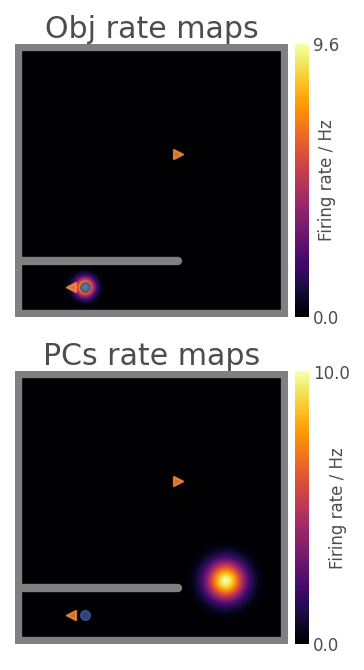

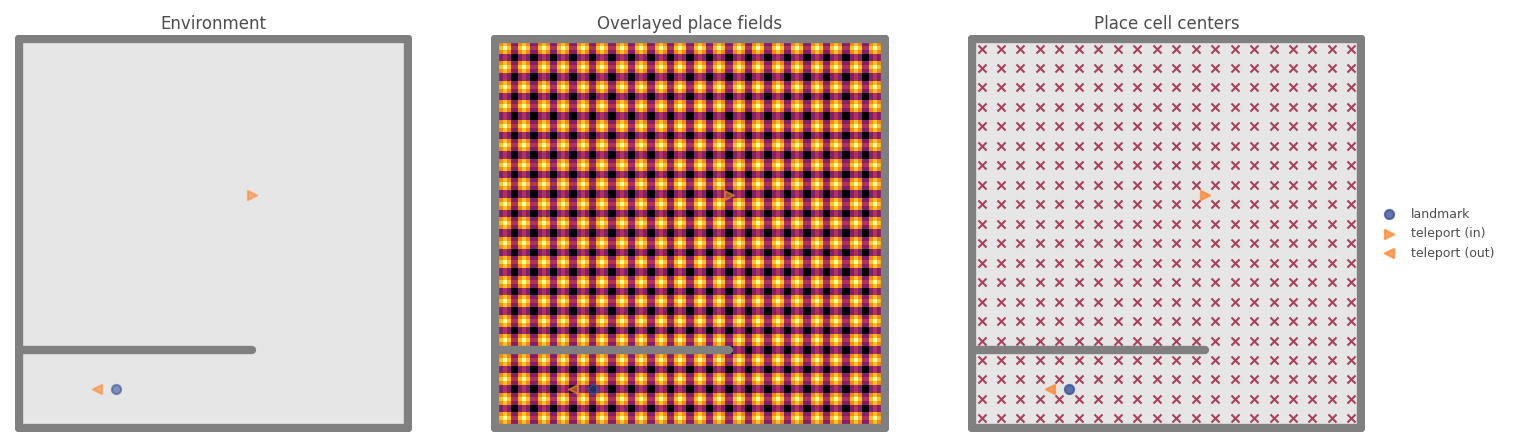

In [5]:
RECORD_WEIGHTS_FREQ = 1000
NUM_STEPS = 15000

Pyr_params = params_util.get_Pyr_params(
    n=1, 
    environment="openfield_corridor",
    log_BTSP=True,
)

Pyrs, fields_axes, aggreg_ax1D = run_manager.init_env_objects(
    Pyr_params=Pyr_params,
    environment="openfield_corridor", 
    plot=True
)

Env, Ag, PCs, Objs = ext_util.extract_objects_from_Pyrs(Pyrs)
updater = run_manager.VNUpdater(Ag)

ALL_FIGURES["fields"] = fields_axes
ALL_FIGURES["fields_aggreg"] = aggreg_ax1D

Target is landmark: True.


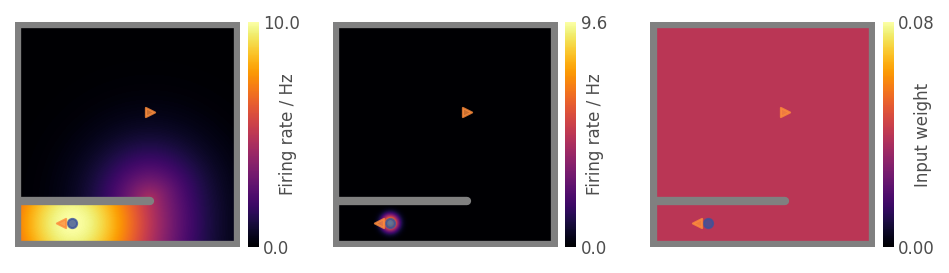

In [6]:
target_is_landmark = (Ag.target_df.loc[len(Ag.target_df) - 1, "object_type_name"] == "landmark")
print(f"Target is landmark: {target_is_landmark}.")

Pyrs.set_learn(False)
Pyrs.set_BTSP_learn(False)

_, ax1D = plt.subplots(1, 3, figsize=(6, 1.5))
updater.VN.plot_rate_map(no_legend=True, ax=ax1D[0])
Objs.plot_rate_map(no_legend=True, ax=ax1D[1])
plot_fcts.plot_2D_PFs(
    Pyrs.ProximalCompartment, alpha=0.3, s=120, plot_BTSP_events=False, no_legend=True, ax=ax1D[2]
)

ALL_FIGURES["field_summary"] = ax1D

## 1. Learn

In [7]:
Ag.enable_teleportation(False)

In [8]:
learner = run_manager.learn_openfield_BTSP(
    Pyrs,
    num_steps_can_stop=NUM_STEPS,
    updater=updater,
    teleportation_enabled=False,
    min_steps_after_BTSP=1000,
)

  0%|          | 0/15000 [00:00<?, ?it/s]

BTSP event recorded at step 1991 (59.73 sec).
BTSP update applied at step 2685 (80.55 sec).
Linear speed mean: 22.84 cm/s, std: 13.54 cm/s.
Reached target 9 times.
Trajectory lengths (8): 56.25 +/- 9.92 sec each
Trajectory lengths (8): 1875.00 +/- 330.72 steps each
1 BTSP event triggered (allowed from step 0): occurred at step 1991.
No weight normalization applied (max value of 0.9083 <= 1).


In [9]:
Pyrs.ProximalCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
Pyrs.ProximalCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP updates applied on average 696.00 steps (20.88 sec.) after they were triggered.
No neuron had at least two BTSP updates triggered.


In [10]:
Ag.trajectory_df

,start_position_x,start_position_y,start_step,start_time,end_position_x,end_position_y,end_step,end_time,num_steps_total,time_total
0,1.300506,0.806444,0,0.0,0.466022,0.059776,2000.0,60.0,2000.0,60.0
1,1.290448,1.396903,2000,60.0,0.083991,0.090675,4000.0,120.0,2000.0,60.0
2,0.308788,1.102746,4000,120.0,1.819950,0.274535,6000.0,180.0,2000.0,60.0
3,0.082951,0.955553,6000,180.0,1.417897,1.472874,8000.0,240.0,2000.0,60.0
4,1.164465,0.847698,8000,240.0,0.692072,1.637991,10000.0,300.0,2000.0,60.0
5,0.391742,1.015904,10000,300.0,1.646563,1.965314,12000.0,360.0,2000.0,60.0
6,1.587388,1.581505,12000,360.0,0.591700,0.098153,14000.0,420.0,2000.0,60.0
7,1.922911,1.756671,14000,420.0,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
Ag.target_df.head()

,object_idx,object_type_name,object_type_num,position_x,position_y,set_step,set_time,random_walk_periods,reached_step,reached_time,num_random_walk_steps,random_walk_time,num_steps_total,time_total
0,0.0,landmark,0.0,0.5,0.2,0,0.00,"[[0, 300], [1018, 1318]]",1985.0,59.55,600.0,18.00,1985.0,59.55
1,NaN,no_target,NaN,NaN,NaN,1985,59.55,"[[1985, 2000]]",NaN,NaN,15.0,0.45,15.0,0.45
2,NaN,no_target,NaN,NaN,NaN,2000,60.00,"[[2000, 2300]]",NaN,NaN,300.0,9.00,300.0,9.00
3,NaN,no_target,NaN,NaN,NaN,2300,69.00,"[[2300, 2600]]",NaN,NaN,300.0,9.00,300.0,9.00
4,0.0,landmark,0.0,0.5,0.2,2600,78.00,"[[2600, 2900], [2900, 3200], [3200, 3500], [35...",NaN,NaN,1200.0,36.00,1400.0,42.00


Linear speed mean: 22.82 cm/s, std: 13.55 cm/s.


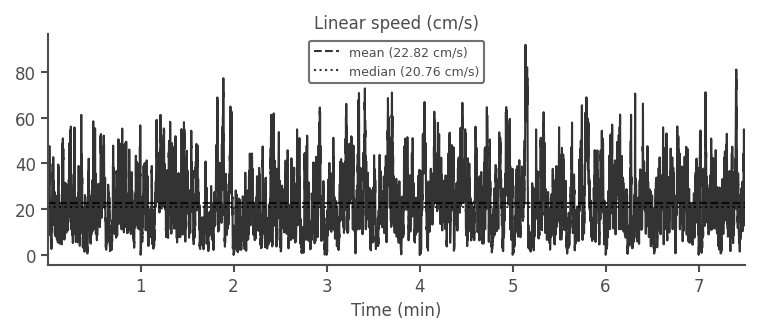

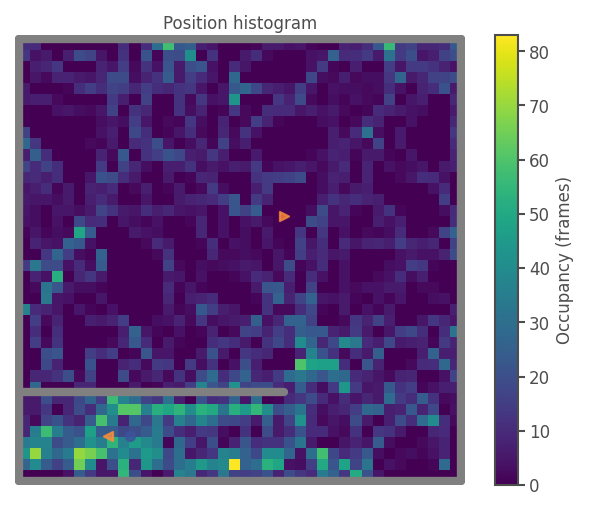

In [12]:
Ag.log_speed_stats()
sub_ax_speed = Ag.plot_speed(mark_mean=True, mark_median=True)
sub_ax_occ = Ag.plot_occupancy(no_legend=True)

ALL_FIGURES["1-initial_speed"] = sub_ax_speed
ALL_FIGURES["1-initial_occupancy"] = sub_ax_occ

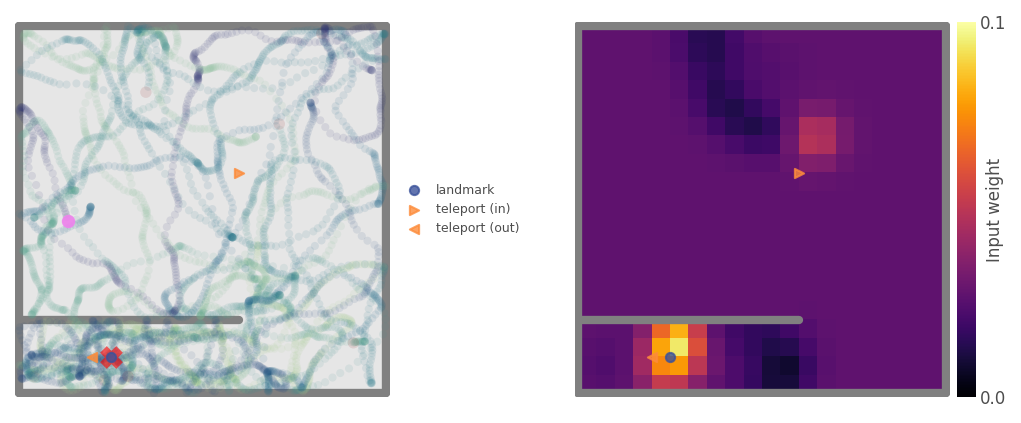

In [13]:
fig, ax1D = plt.subplots(1, 2, figsize=[7, 2.5])
Ag.plot_trajectories(alpha=0.1, ax=ax1D[0])

plot_fcts.plot_2D_PFs(
    Pyrs.ProximalCompartment, alpha=0.3, s=380, plot_BTSP_events=True, no_legend=True, ax=ax1D[1]
)

ALL_FIGURES["1-initial_spatial"] = ax1D

/home/cgillon/homedir/predhpc/predhpc/util/learn_util.py:819: UserWarning: Assessment will assume geodesic wall geometry even though place cell wall geometry is line_of_sight.
  warnings.warn(


Update 1 regul.: 0.9236 (w)


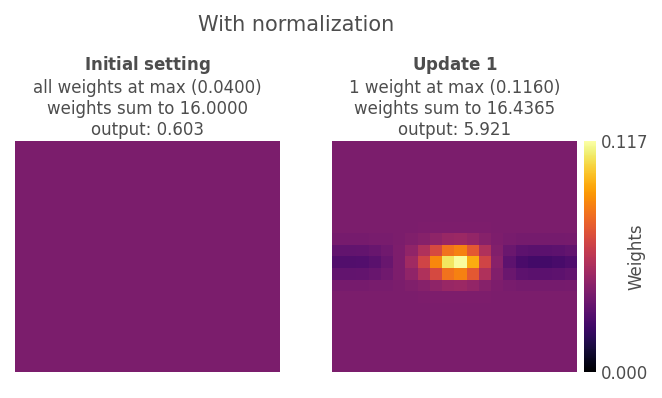

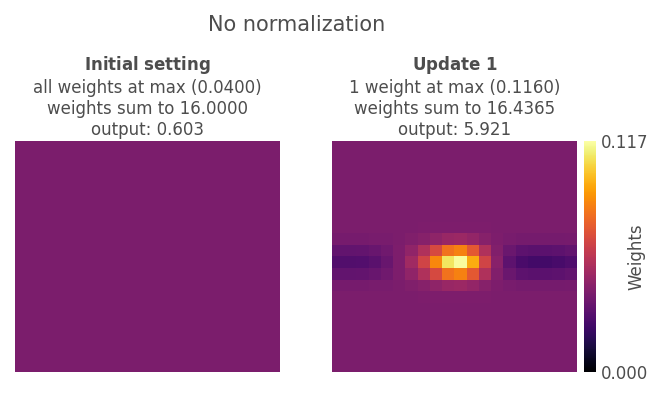

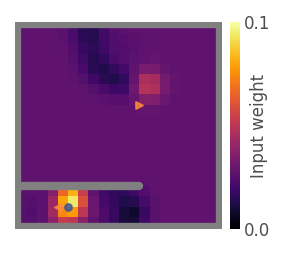

In [14]:
norm_theor_axes, no_norm_theor_axes, act_sub_ax = plot_fcts.compare_theoretical_and_true_weights(
    learner.Pyrs.ProximalCompartment,
    output_fr=4.2, # tuned to match actual weights
)

ALL_FIGURES["BTSP_kernel_norm"] = norm_theor_axes
ALL_FIGURES["BTSP_kernel"] = no_norm_theor_axes
ALL_FIGURES["1-initial_actual_weights"] = act_sub_ax

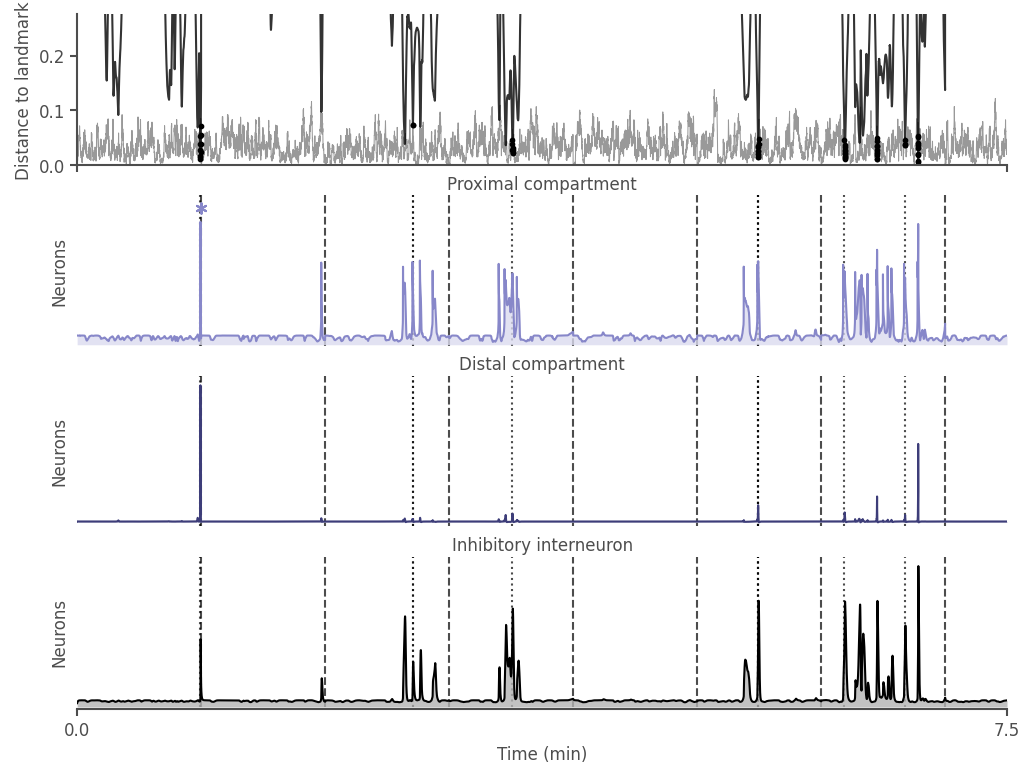

In [15]:
tol_prop_to_speed_dt = Ag.target_reached_within_tol_prop_to_speed_dt

fig, ax1D = plt.subplots(4, 1, figsize=[8, 6], sharex=True)
Ag.plot_distance_to(
    position_name="landmark", 
    mark_below_tolerance=True, 
    tol_prop_to_speed_dt=tol_prop_to_speed_dt,
    zoom_prop=2,
    sub_ax=ax1D[0]
    )
ax1D[0].set_xlabel("")

Pyrs.plot_rate_timeseries(separate_axes=True, ax=ax1D[1:])

ALL_FIGURES["1-initial_distance_to_target_single"] = ax1D

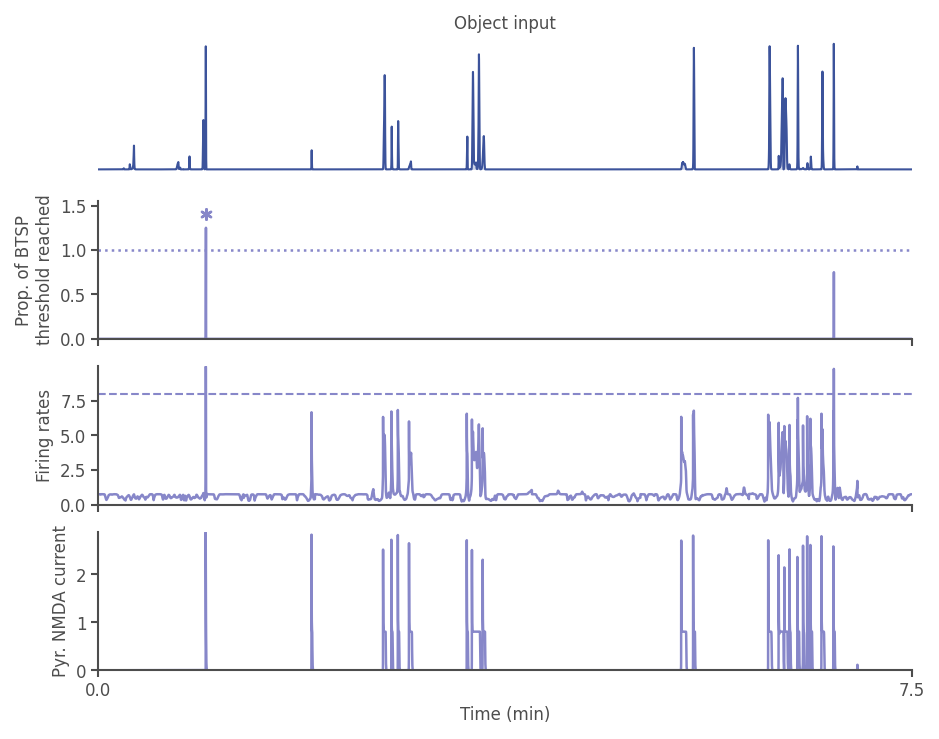

In [16]:
fig, ax1D = plt.subplots(4, 1, figsize=[7, 5.5], sharex=True)

Objs.plot_rate_timeseries(sub_ax=ax1D[0])
ax1D[0].set_title("Object input")
ax1D[0].set_ylabel("")
plot_util.clear_bottom(ax1D[0])

Pyrs.ProximalCompartment.plot_BTSP_ramp_factors(axes=ax1D[1:])

ALL_FIGURES["1-initial_BTSP_timeseries"] = ax1D

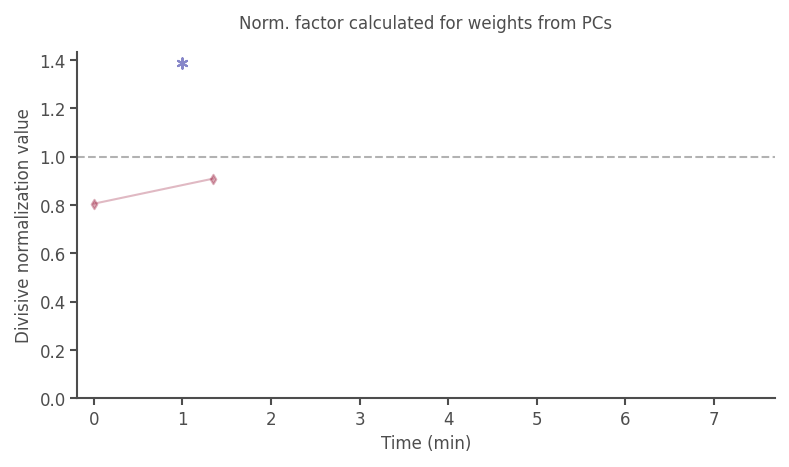

In [17]:
if Pyrs.ProximalCompartment.normalize_weights_divisively:
    sub_ax = Pyrs.ProximalCompartment.plot_normalization_values(input_layer="PCs")
    ALL_FIGURES["1-initial_weight_norm_time"] = sub_ax

## 2. Enable teleportation

In [18]:
initial_end_time = Ag.t
Ag.enable_teleportation(True)
Ag.update_target_probability_factor_dict("teleport", 5)
Ag.update_target_probability_factor_dict("no_target", 1)

In [19]:
Ag.get_target_probability_df()

,object_df_idx,object_type_num,object_type_name,idx_within_type,position_x,position_y,teleport_pair_idx,teleport_direction,target_factor,target_probability
0,0.0,0.0,landmark,0.0,0.5,0.2,NaN,NaN,1.0,0.142857
1,1.0,1.0,teleport_0_in,0.0,1.2,1.2,0.0,in,5.0,0.714286
2,NaN,NaN,no_target,NaN,NaN,NaN,NaN,NaN,1.0,0.142857


In [20]:
learner_with_teleport = Pyrs

num_BTSP = len(Pyrs.ProximalCompartment.history["BTSP_events"])
teleport_start_time = Ag.t

learner_with_teleport = run_manager.learn_openfield_BTSP(
    Pyrs_or_learner=learner_with_teleport,
    teleportation_enabled=True,
    num_steps_can_stop=8000,
    min_steps_after_BTSP=2000,
    updater=updater,
    min_num_teleports=1,
)

teleport_idx = len(Ag.teleportation_df) - 1

  0%|          | 0/8000 [00:00<?, ?it/s]

Continuing learning for up to 20000 steps until 2000 steps since last BTSP event was applied and at least 1 teleportation events have occurred.


  0%|          | 0/20000 [00:00<?, ?it/s]

Teleported through pair 0 at step 29890 (896.70 sec).
BTSP event recorded at step 29895 (896.85 sec).
BTSP update applied at step 30589 (917.67 sec).
Linear speed mean: 23.08 cm/s, std: 13.28 cm/s.
Reached target 22 times.
Trajectory lengths (17): 57.52 +/- 9.94 sec each
Trajectory lengths (17): 1917.18 +/- 331.29 steps each
1 BTSP event triggered (allowed from step 15000): occurred at step 29895.
Max. weight normalization value applied: 1.1364.


In [21]:
print(f"{int(Pyrs.ProximalCompartment.get_BTSP_counts()[0])} BTSP events recorded in total.")

2 BTSP events recorded in total.


In [22]:
Ag.target_df

,object_idx,object_type_name,object_type_num,position_x,position_y,set_step,set_time,random_walk_periods,reached_step,reached_time,num_random_walk_steps,random_walk_time,num_steps_total,time_total
0,0.0,landmark,0.0,0.5,0.2,0,0.00,"[[0, 300], [1018, 1318]]",1985.0,59.55,600.0,18.00,1985.0,59.55
1,NaN,no_target,NaN,NaN,NaN,1985,59.55,"[[1985, 2000]]",NaN,NaN,15.0,0.45,15.0,0.45
2,NaN,no_target,NaN,NaN,NaN,2000,60.00,"[[2000, 2300]]",NaN,NaN,300.0,9.00,300.0,9.00
3,NaN,no_target,NaN,NaN,NaN,2300,69.00,"[[2300, 2600]]",NaN,NaN,300.0,9.00,300.0,9.00
4,0.0,landmark,0.0,0.5,0.2,2600,78.00,"[[2600, 2900], [2900, 3200], [3200, 3500], [35...",NaN,NaN,1200.0,36.00,1400.0,42.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1.0,teleport_0_in,1.0,1.2,1.2,30145,904.35,[],30146.0,904.38,0.0,0.00,1.0,0.03
65,1.0,teleport_0_in,1.0,1.2,1.2,30146,904.38,[],30147.0,904.41,0.0,0.00,1.0,0.03
66,1.0,teleport_0_in,1.0,1.2,1.2,30147,904.41,[],30149.0,904.47,0.0,0.00,2.0,0.06
67,1.0,teleport_0_in,1.0,1.2,1.2,30149,904.47,[],NaN,NaN,0.0,0.00,1851.0,55.53


In [23]:
Ag.log_teleportation()
Ag.trajectory_df

Teleportation events:
    through pair 0 at step 29890 (896.70 sec.)


,start_position_x,start_position_y,start_step,start_time,end_position_x,end_position_y,end_step,end_time,num_steps_total,time_total
0,1.300506,0.806444,0,0.0,0.466022,0.059776,2000.0,60.0,2000.0,60.0
1,1.290448,1.396903,2000,60.0,0.083991,0.090675,4000.0,120.0,2000.0,60.0
2,0.308788,1.102746,4000,120.0,1.819950,0.274535,6000.0,180.0,2000.0,60.0
3,0.082951,0.955553,6000,180.0,1.417897,1.472874,8000.0,240.0,2000.0,60.0
4,1.164465,0.847698,8000,240.0,0.692072,1.637991,10000.0,300.0,2000.0,60.0
5,0.391742,1.015904,10000,300.0,1.646563,1.965314,12000.0,360.0,2000.0,60.0
6,1.587388,1.581505,12000,360.0,0.591700,0.098153,14000.0,420.0,2000.0,60.0
7,1.922911,1.756671,14000,420.0,0.210245,0.107284,16000.0,480.0,2000.0,60.0
8,0.681025,1.491075,16000,480.0,0.663808,0.303923,18000.0,540.0,2000.0,60.0
9,1.638864,0.945480,18000,540.0,0.796714,1.542437,20000.0,600.0,2000.0,60.0


In [24]:
Ag.teleportation_df

,teleport_pair_idx,step_num,time,in_object_idx,in_object_type_num,in_object_type_name,in_position_x,in_position_y,in_vector_x,in_vector_y,...,in_velocity_y,out_object_idx,out_object_type_num,out_object_type_name,out_position_x,out_position_y,out_vector_x,out_vector_y,out_velocity_x,out_velocity_y
0,0,29890,896.7,1,1,teleport_0_in,1.120741,1.237862,-0.079259,0.037862,...,0.219784,2,2,teleport_0_out,0.479259,0.162138,0.079259,-0.037862,0.34086,0.219784


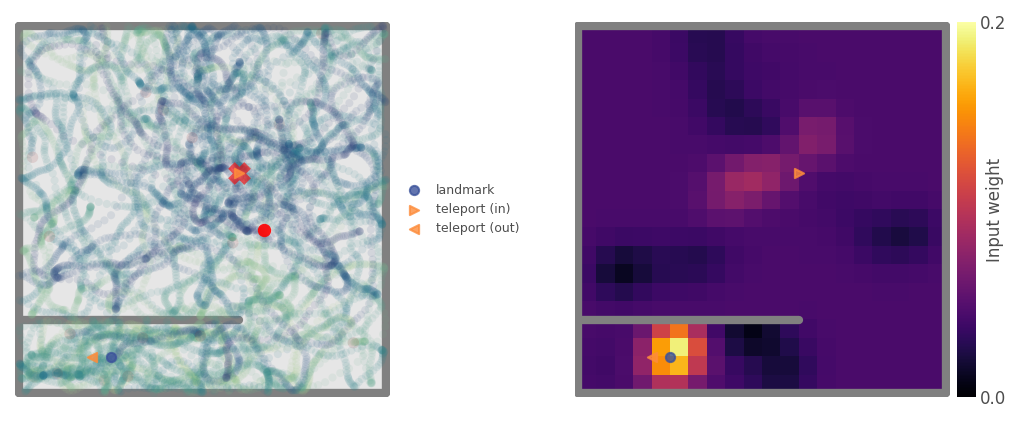

In [25]:
fig, ax1D = plt.subplots(1, 2, figsize=[7, 2.5])
Ag.plot_trajectories(alpha=0.1, ax=ax1D[0])

plot_fcts.plot_2D_PFs(
    Pyrs.ProximalCompartment, alpha=0.3, s=380, plot_BTSP_events=True, no_legend=True, ax=ax1D[1]
)

ALL_FIGURES["2-with_teleport_spatial"] = ax1D

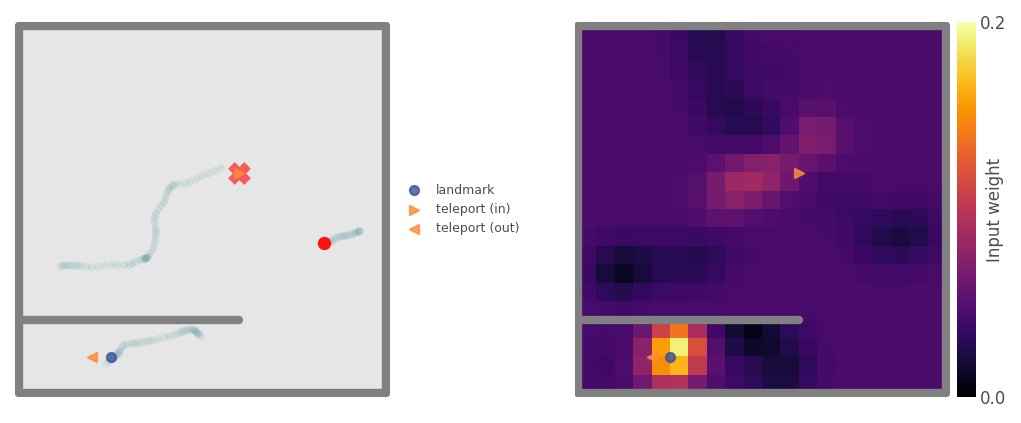

In [26]:
# visualize weights after a specific BTSP event
event_idx = 0 # from when teleport was allowed

last_teleport_time = Ag.teleportation_df.loc[teleport_idx, "time"]
recorded_weights_with_teleport = learner_with_teleport.get_recorded_weights()

teleport_weights = recorded_weights_with_teleport["weights"]
teleport_weight_time = recorded_weights_with_teleport["times"]
if len(teleport_weights) > event_idx + 1:
    fig, ax1D = plt.subplots(1, 2, figsize=[7, 2.5])
    Ag.plot_trajectories(alpha=0.1, ax=ax1D[0], t_start=last_teleport_time - 5, t_end=last_teleport_time + 5)
    
    plot_fcts.plot_2D_PFs(
        Pyrs.ProximalCompartment, 
        PFs=teleport_weights[event_idx + 1], 
        t_end=teleport_weight_time[event_idx + 1],
        alpha=0.3, 
        s=380,
        plot_BTSP_events=True, 
        no_legend=True, 
        ax=ax1D[1]
    )
    
    ALL_FIGURES["2-with_teleport_spatial_first"] = ax1D

In [27]:
Pyrs.ProximalCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
Pyrs.ProximalCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP updates applied on average 696.00 steps (20.88 sec.) after they were triggered.
Shortest interval between applying and subsequently triggering a BTSP update in the same neuron was 27208 steps (816.24 sec.).


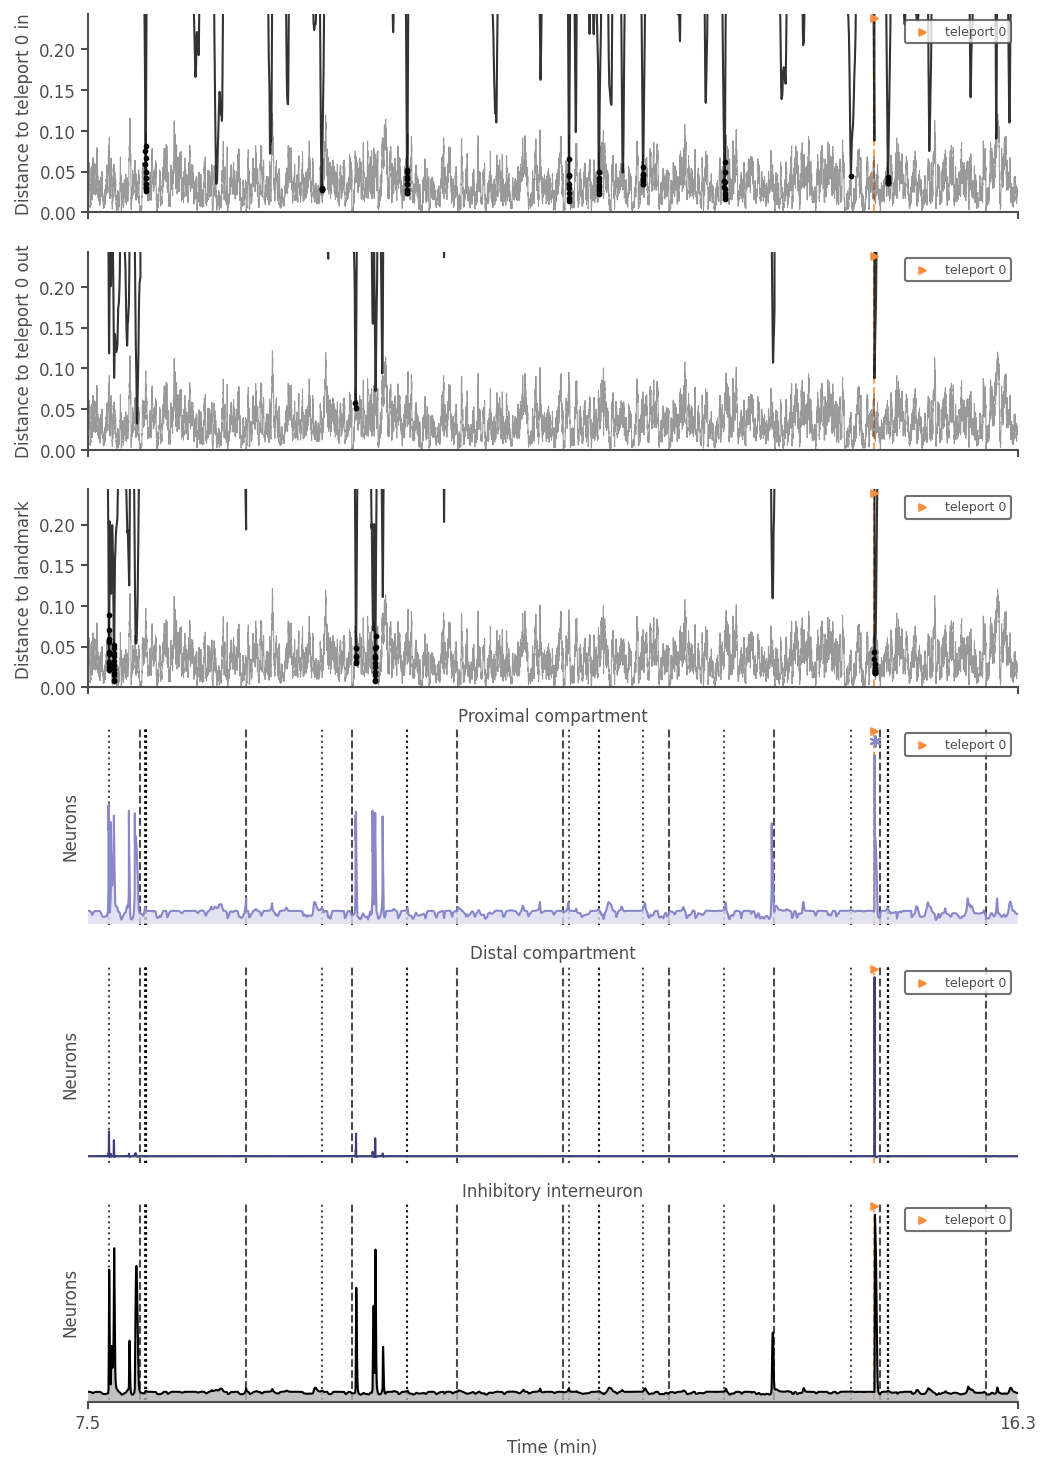

In [28]:
tol_prop_to_speed_dt = Ag.target_reached_within_tol_prop_to_speed_dt

names = ["teleport_0_in", "teleport_0_out", "landmark"]

fig, ax1D = plt.subplots(6, 1, figsize=[8, 12], sharex=True)
for i, name in enumerate(names):
    Ag.plot_distance_to(
        position_name=name, 
        sub_ax=ax1D[i],
        mark_below_tolerance=True, 
        tol_prop_to_speed_dt=tol_prop_to_speed_dt,
        zoom_prop=2,
        t_start=teleport_start_time,
    )
    ax1D[i].set_xlabel("")

Pyrs.plot_rate_timeseries(separate_axes=True, ax=ax1D[3:], t_start=teleport_start_time)

Ag.add_teleportation_markers_to_plots(ax=ax1D, t_start=teleport_start_time, timeseries=True)

for sub_ax in ax1D:
    sub_ax.legend(loc="upper right")

ALL_FIGURES["2-with_teleport_distance_to_target_single"] = ax1D

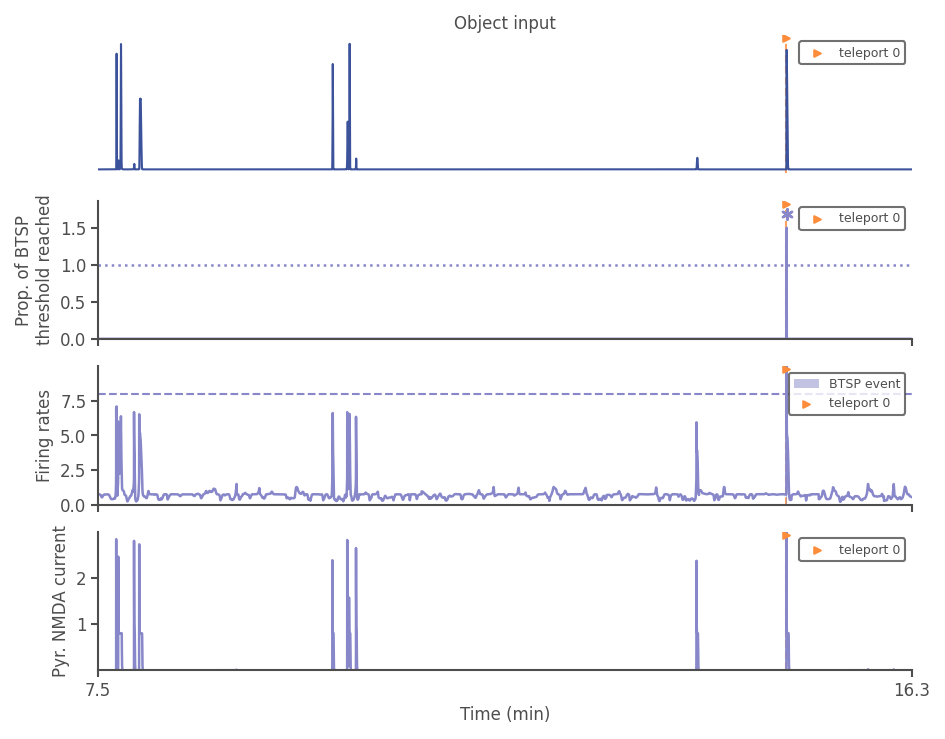

In [29]:
fig, ax1D = plt.subplots(4, 1, figsize=[7, 5.5], sharex=True)

Objs.plot_rate_timeseries(sub_ax=ax1D[0], t_start=teleport_start_time)
ax1D[0].set_title("Object input")
ax1D[0].set_ylabel("")
plot_util.clear_bottom(ax1D[0])

Pyrs.ProximalCompartment.plot_BTSP_ramp_factors(axes=ax1D[1:], t_start=teleport_start_time)
Ag.add_teleportation_markers_to_plots(ax=ax1D, t_start=teleport_start_time, timeseries=True)

for sub_ax in ax1D:
    sub_ax.legend(loc="upper right")

ALL_FIGURES["2-with_teleport_BTSP_timeseries"] = ax1D

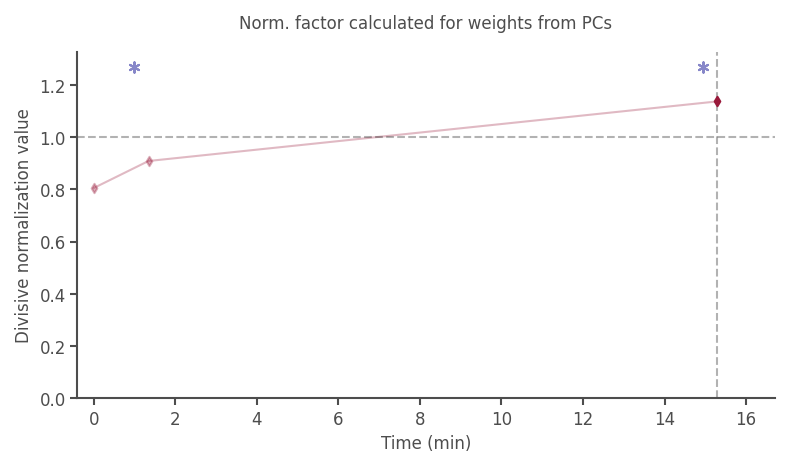

In [30]:
if Pyrs.ProximalCompartment.normalize_weights_divisively:
    sub_ax = Pyrs.ProximalCompartment.plot_normalization_values(input_layer="PCs")
    ALL_FIGURES["2-with_teleport_weight_norm_time"] = sub_ax

## 3. Additional teleportation events
Does not always work as the teleportation events are a bit improbable. 

In [31]:
additional_teleport_start_time = Ag.t

In [32]:
num_teleportations = len(Ag.teleportation_df)

learner_with_teleport = run_manager.learn_openfield_BTSP(
    Pyrs_or_learner=learner_with_teleport,
    teleportation_enabled=True,
    num_steps_can_stop=30000,
    min_steps_after_BTSP=2000,
    updater=updater,
    min_num_teleports=num_teleportations + 3,
)

  0%|          | 0/30000 [00:00<?, ?it/s]

Teleported through pair 0 at step 32941 (988.23 sec).
BTSP event recorded at step 32945 (988.35 sec).
BTSP update applied at step 33639 (1009.17 sec).
Teleported through pair 0 at step 36674 (1100.22 sec).
BTSP event recorded at step 36679 (1100.37 sec).
BTSP update applied at step 37373 (1121.19 sec).
Teleported through pair 0 at step 39214 (1176.42 sec).
Teleported through pair 0 at step 42093 (1262.79 sec).
Teleported through pair 0 at step 52390 (1571.70 sec).
BTSP event recorded at step 52394 (1571.82 sec).
BTSP update applied at step 53088 (1592.64 sec).
Teleported through pair 0 at step 57099 (1712.97 sec).
Linear speed mean: 23.16 cm/s, std: 13.09 cm/s.
Reached target 63 times.
Trajectory lengths (32): 58.68 +/- 7.35 sec each
Trajectory lengths (32): 1956.00 +/- 244.98 steps each
4 BTSP events triggered (allowed from step 15000): occurred between steps 29895 and 52394, inclusively.
Max. weight normalization value applied: 1.2970.


In [33]:
print(f"{int(Pyrs.ProximalCompartment.get_BTSP_counts()[0])} BTSP events recorded in total.")

5 BTSP events recorded in total.


In [34]:
Pyrs.Agent.teleportation_df

,teleport_pair_idx,step_num,time,in_object_idx,in_object_type_num,in_object_type_name,in_position_x,in_position_y,in_vector_x,in_vector_y,...,in_velocity_y,out_object_idx,out_object_type_num,out_object_type_name,out_position_x,out_position_y,out_vector_x,out_vector_y,out_velocity_x,out_velocity_y
0,0,29890,896.70,1,1,teleport_0_in,1.120741,1.237862,-0.079259,0.037862,...,0.219784,2,2,teleport_0_out,0.479259,0.162138,0.079259,-0.037862,0.340860,0.219784
1,0,32941,988.23,1,1,teleport_0_in,1.120399,1.207651,-0.079601,0.007651,...,-0.251340,2,2,teleport_0_out,0.479601,0.192349,0.079601,-0.007651,0.318962,-0.251340
2,0,36674,1100.22,1,1,teleport_0_in,1.138303,1.233761,-0.061697,0.033761,...,0.227295,2,2,teleport_0_out,0.461697,0.166239,0.061697,-0.033761,0.278774,0.227295
3,0,39214,1176.42,1,1,teleport_0_in,1.115726,1.222573,-0.084274,0.022573,...,0.025061,2,2,teleport_0_out,0.484274,0.177427,0.084274,-0.022573,0.390357,0.025061
4,0,42093,1262.79,1,1,teleport_0_in,1.121653,1.254860,-0.078347,0.054860,...,-0.268387,2,2,teleport_0_out,0.478347,0.145140,0.078347,-0.054860,0.416540,-0.268387
5,0,52390,1571.70,1,1,teleport_0_in,1.124905,1.194049,-0.075095,-0.005951,...,0.179179,2,2,teleport_0_out,0.475095,0.205951,0.075095,0.005951,0.366935,0.179179
6,0,57099,1712.97,1,1,teleport_0_in,1.175182,1.179017,-0.024818,-0.020983,...,0.060764,2,2,teleport_0_out,0.424818,0.220983,0.024818,0.020983,0.198764,0.060764


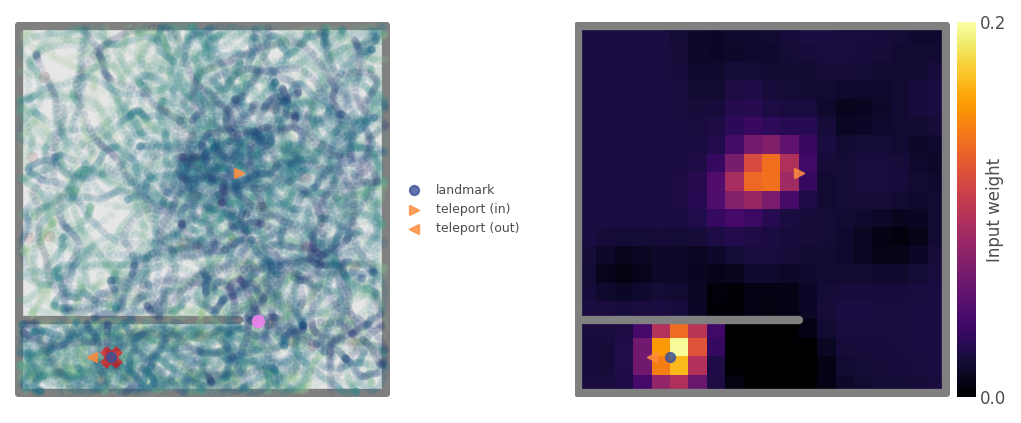

In [35]:
fig, ax1D = plt.subplots(1, 2, figsize=[7, 2.5])
Ag.plot_trajectories(alpha=0.1, ax=ax1D[0])

plot_fcts.plot_2D_PFs(
    Pyrs.ProximalCompartment, alpha=0.3, s=380, plot_BTSP_events=True, no_legend=True, ax=ax1D[1]
)

ALL_FIGURES["3-additional_teleport_spatial"] = ax1D

In [36]:
Pyrs.ProximalCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
Pyrs.ProximalCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP updates applied on average 696.00 steps (20.88 sec.) after they were triggered.
Shortest interval between applying and subsequently triggering a BTSP update in the same neuron was 2354 steps (70.62 sec.).


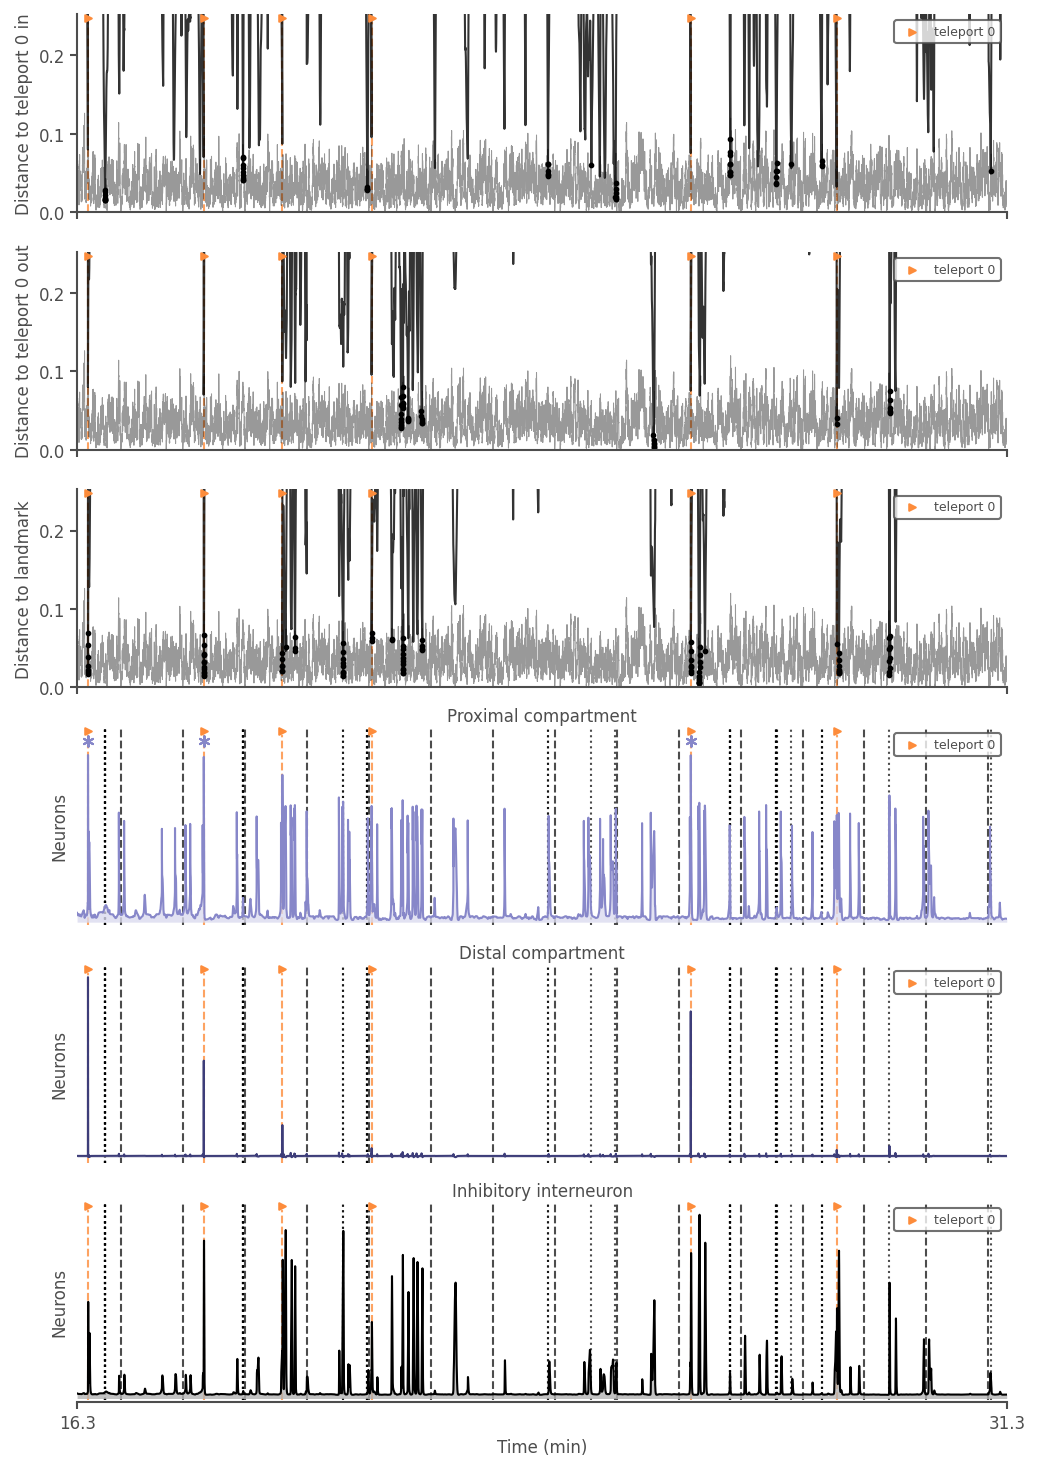

In [37]:
tol_prop_to_speed_dt = Ag.target_reached_within_tol_prop_to_speed_dt

names = ["teleport_0_in", "teleport_0_out", "landmark"]

fig, ax1D = plt.subplots(6, 1, figsize=[8, 12], sharex=True)
for i, name in enumerate(names):
    Ag.plot_distance_to(
        position_name=name, 
        sub_ax=ax1D[i],
        mark_below_tolerance=True, 
        tol_prop_to_speed_dt=tol_prop_to_speed_dt,
        zoom_prop=2,
        t_start=additional_teleport_start_time,
    )
    ax1D[i].set_xlabel("")

Pyrs.plot_rate_timeseries(separate_axes=True, ax=ax1D[3:], t_start=additional_teleport_start_time)

Ag.add_teleportation_markers_to_plots(ax=ax1D, t_start=additional_teleport_start_time, timeseries=True)

for sub_ax in ax1D:
    sub_ax.legend(loc="upper right")

ALL_FIGURES["3-additional_teleport_distance_to_target_single"] = ax1D

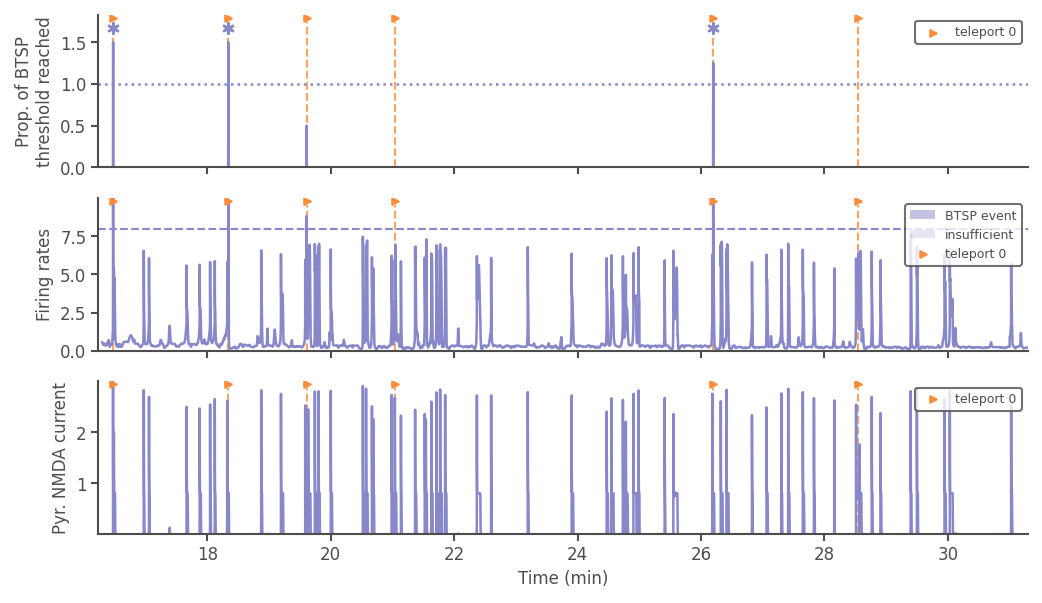

In [38]:
fig, ax1D = plt.subplots(3, 1, figsize=[8, 4.5], sharex=True)
Pyrs.ProximalCompartment.plot_BTSP_ramp_factors(axes=ax1D, t_start=additional_teleport_start_time)
Ag.add_teleportation_markers_to_plots(ax=ax1D, t_start=additional_teleport_start_time, timeseries=True)

for sub_ax in ax1D:
    sub_ax.legend(loc="upper right")

ALL_FIGURES["3-additional_teleport_BTSP_timeseries"] = ax1D

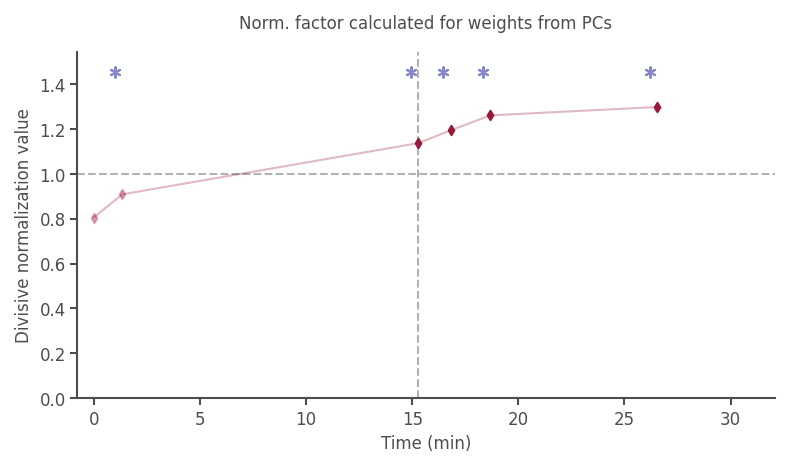

In [39]:
if Pyrs.ProximalCompartment.normalize_weights_divisively:
    sub_ax = Pyrs.ProximalCompartment.plot_normalization_values(input_layer="PCs")
    ALL_FIGURES["3-additional_teleport_weight_norm_time"] = sub_ax

## 4. Save and animate

### Save figures

In [40]:
SAVE = True

In [ ]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        fig = ax.ravel()[0].figure if isinstance(ax, np.ndarray) else ax.figure
        plot_util.save_figure(fig, key, save=True)        

### Animate

In [42]:
ANIMATE = True

In [43]:
if ANIMATE:
    all_learners = [
        learner, 
        learner_with_teleport
    ]

    all_weight_dicts = [curr_learner.get_recorded_weights() for curr_learner in all_learners]
    combined_weights = {
        key: np.concatenate([weight_dict[key] for weight_dict in all_weight_dicts]).tolist() 
        for key in all_weight_dicts[0].keys()
    }

    all_animate_kwargs = {
        "Pyrs": Pyrs,
        "Pyrs_weights": combined_weights["weights"],
        "Pyrs_weights_t": combined_weights["times"],
        "speed_up": 10,
        "s": 400,
        "environment": "openfield",
        "plot_positions": ["landmark"],
        "reached_only": False,
        "embed_limit": 85.0,
        "anim_save_types": ["mp4"],
        "autosave": True,
    }

### 1-Initial conditions
Animation takes about 10 min to create.

In [ ]:
if ANIMATE:
    anim = animate_util.animate(
        t_end=initial_end_time, 
        savename="1-initial_timeseries",
        addendum="teleportation disabled",
        **all_animate_kwargs
    )
    anim

### 2-With teleportation
Animation takes about 25 min to create.

In [ ]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=teleport_start_time,
        savename="2-with_teleport_timeseries",
        addendum="teleportation enabled",
        **all_animate_kwargs
    )
    anim